# Hypothesis 1: Sale price varies by period of the year
**Research Question:** Does the timing of the sale affect price?
This analysis looks at average price by month, both for the full dataset 
and specifically for middle-class zipcodes, since that is Bonnie's market 
segment.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/eda.csv")

In [25]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")
df["sale_month"] = df["date"].dt.month

In [26]:
avg_price_by_zip = df.groupby("zipcode")["price"].mean().sort_values()

lower_cutoff = avg_price_by_zip.quantile(0.33)
upper_cutoff = avg_price_by_zip.quantile(0.67)

middle_class_zips = avg_price_by_zip[(avg_price_by_zip >= lower_cutoff) & (avg_price_by_zip <= upper_cutoff)]

## Average price by month (all zipcodes)

Here we calculate the average price for each month, using the full dataset 
(all zipcodes, not just middle-class).

In [27]:
avg_price_by_month = df.groupby("sale_month")["price"].mean().sort_values(ascending=False)
avg_price_by_month

sale_month
4     562215.615074
6     557534.318182
5     550849.746893
7     544892.161013
3     544057.683200
10    539439.447228
8     536655.212481
9     529723.517787
1     525963.251534
12    524799.902041
11    522359.903478
2     508520.051323
Name: price, dtype: float64

## Filter for middle-class zipcodes

Now we apply the middle-class zipcode filter, so the rest of the analysis 
focuses only on Bonnie's market segment.

In [28]:
df_middle_class = df[df["zipcode"].isin(middle_class_zips.index)]
df_middle_class.shape

(7532, 22)

## Average price by month (middle-class zipcodes)

Now we repeat the same calculation, but only using houses in middle-class 
zipcodes, since that is Bonnie's market segment.

In [29]:
avg_price_by_month_middle = df_middle_class.groupby("sale_month")["price"].mean().sort_values(ascending=False)
avg_price_by_month_middle

sale_month
4     541898.038023
7     522553.815824
1     521477.507331
10    519218.414634
3     518483.067103
6     516604.239951
11    514889.567404
5     514235.388954
12    508526.556436
8     503794.862170
2     501244.390777
9     497588.241611
Name: price, dtype: float64

## Highest price month 
A quick way to check the exact month and value with the highest average price

In [30]:
print(f"Highest price month: {avg_price_by_month_middle.idxmax()}")
print(f"Highest price value: {avg_price_by_month_middle.max():,.0f}")

Highest price month: 4
Highest price value: 541,898


April still has the highest price. But the lowest-price month changes — 
February in the full dataset, September in middle-class zipcodes. This 
shows the pattern is not the same for every segment.

## How big is the price difference?

Now let's check how much higher April is compared to the lowest month.

In [31]:
price_difference_middle = avg_price_by_month_middle.max() - avg_price_by_month_middle.min()
price_percentage_middle = (price_difference_middle / avg_price_by_month_middle.min()) * 100
print(price_difference_middle, price_percentage_middle)

44309.79641207546 8.904912276190577


## Chart: price by month (middle-class zipcodes)

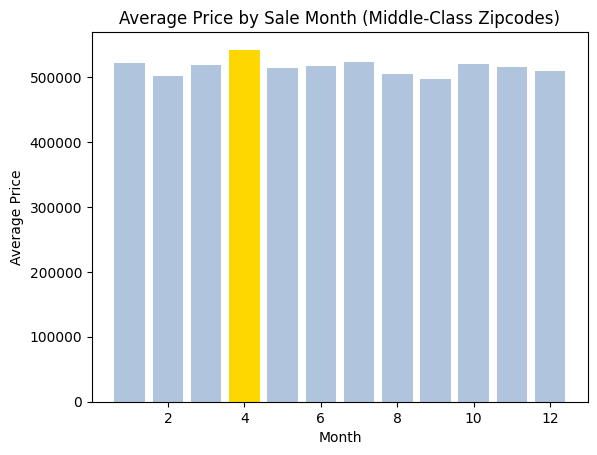

In [32]:
highlight_colour = "#FFD700"
default_colour = "#B0C4DE"

bar_colours = [highlight_colour if month == 4 else default_colour for month in avg_price_by_month_middle.sort_index().index]

fig, ax = plt.subplots()
ax.bar(avg_price_by_month_middle.sort_index().index, avg_price_by_month_middle.sort_index().values, color=bar_colours)
ax.set_title("Average Price by Sale Month (Middle-Class Zipcodes)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price")
plt.show()

## Chart: price by month (all zipcodes)

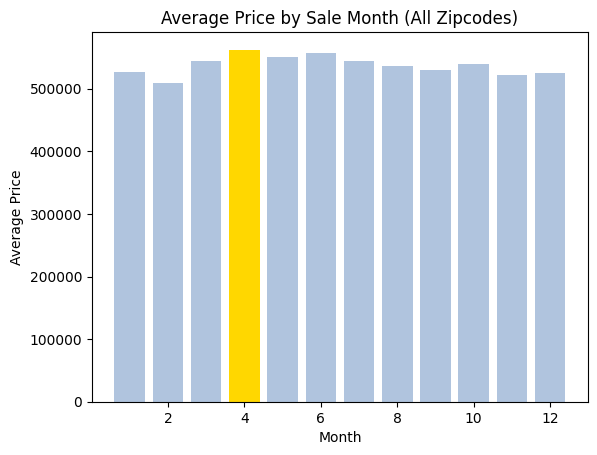

In [33]:
highlight_colour = "#FFD700"
default_colour = "#B0C4DE"

bar_colours = [highlight_colour if month == 4 else default_colour for month in avg_price_by_month.sort_index().index]

fig, ax = plt.subplots()
ax.bar(avg_price_by_month.sort_index().index, avg_price_by_month.sort_index().values, color=bar_colours)
ax.set_title("Average Price by Sale Month (All Zipcodes)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Price")
plt.show()

April is the highest-price month in both charts — all zipcodes and 
middle-class zipcodes. This shows the pattern holds across the whole 
market, not just one segment.

The result varies a little, but it's not significant.

---
## Additional exploration

## Number of sales by month

In [34]:
sales_count_by_month = df.groupby("sale_month")["price"].count().sort_index()
sales_count_by_month

sale_month
1      978
2     1247
3     1875
4     2229
5     2414
6     2178
7     2211
8     1939
9     1771
10    1876
11    1409
12    1470
Name: price, dtype: int64

How much does the number of sales change by month?


In [35]:
sales_difference = sales_count_by_month.max() - sales_count_by_month.min()
sales_percentage = (sales_difference / sales_count_by_month.min()) * 100
print(sales_difference, sales_percentage)

1436 146.83026584867076


Average price only changes a little by month (about 9%). But the number 
of houses sold changes a lot, May had 147% more sales than January. 
Timing seems to matter more for market activity than for price.

## Chart: number of sales by month

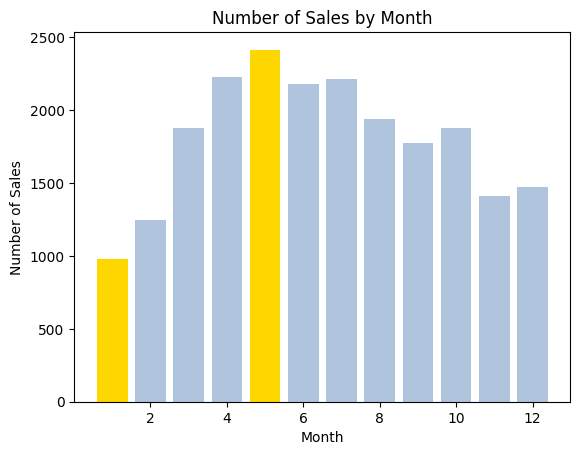

In [36]:
highlight_colour = "#FFD700"
default_colour = "#B0C4DE"

bar_colours = [highlight_colour if (month == 1 or month == 5) else default_colour for month in sales_count_by_month.index]

fig, ax = plt.subplots()
ax.bar(sales_count_by_month.index, sales_count_by_month.values, color=bar_colours)
ax.set_title("Number of Sales by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Sales")
plt.show()

The number of house sales changes a lot by month. It's highest in May 
and lowest in January. This pattern is much stronger than the one we 
saw with price.

## Is price connected to number of sales?

In [37]:
comparison = pd.DataFrame({
    "avg_price": avg_price_by_month.sort_index(),
    "sales_count": sales_count_by_month.sort_index()
})
comparison

,avg_price,sales_count
sale_month,,
1,525963.251534,978
2,508520.051323,1247
3,544057.683200,1875
4,562215.615074,2229
5,550849.746893,2414
6,557534.318182,2178
7,544892.161013,2211
8,536655.212481,1939
9,529723.517787,1771


In [38]:
comparison.corr()

,avg_price,sales_count
avg_price,1.000000,0.861285
sales_count,0.861285,1.000000


There is a strong connection between average price and the number of 
sales per month (0.86 out of 1). This means that in months with more 
house sales, the average price also tends to be higher. Both patterns 
move together — more buyers looking for houses can push prices up.